## Prediction Error Plot

### Prediction Error Plot – Regression

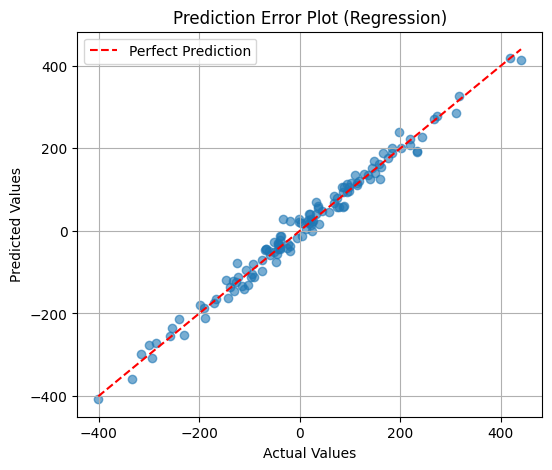

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Data
X, y = make_regression(n_samples=500, noise=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label="Perfect Prediction")

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Prediction Error Plot (Regression)")
plt.legend()
plt.grid()
plt.show()


### Prediction Error Plot – Residual Plot

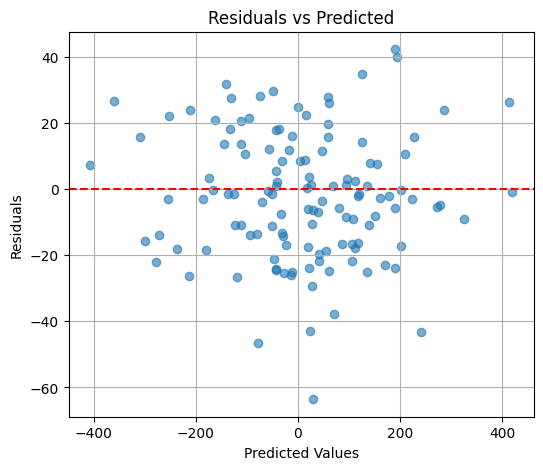

In [2]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid()
plt.show()


### Prediction Error Plot – Classification

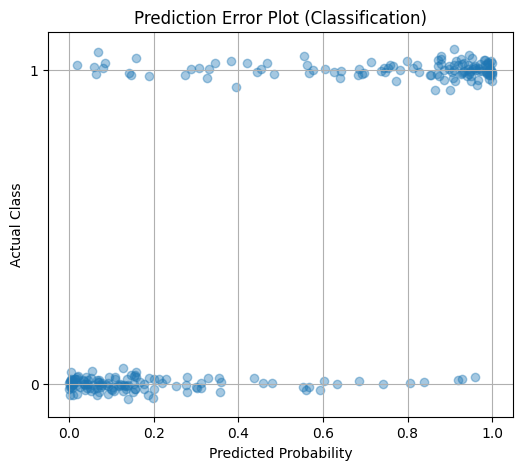

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Data
X, y = make_classification(n_samples=1000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y)

# Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Plot
plt.figure(figsize=(6, 5))
plt.scatter(y_prob, y_test + np.random.normal(0, 0.02, size=len(y_test)),
            alpha=0.4)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Class")
plt.title("Prediction Error Plot (Classification)")
plt.yticks([0, 1])
plt.grid()
plt.show()


### Prediction Error Distribution (Histogram)

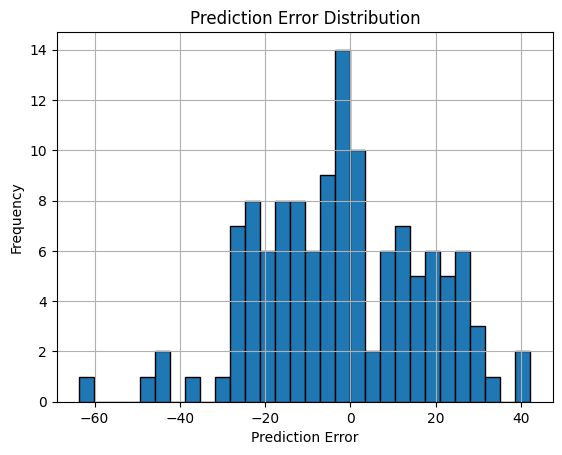

In [4]:
plt.hist(residuals, bins=30, edgecolor="black")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.grid()
plt.show()


### Yellowbrick Prediction Error Plot (Optional)

In [6]:
! pip install yellowbrick

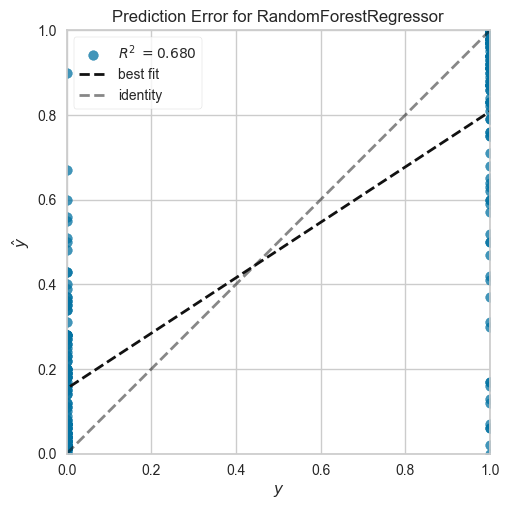

<Axes: title={'center': 'Prediction Error for RandomForestRegressor'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [7]:
from yellowbrick.regressor import PredictionError
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
viz = PredictionError(model)

viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show()
